In this section, we load the **AG News** dataset and use the `bert-base-uncased` tokenizer to convert raw text into fixed-length numerical tensors (128 tokens) suitable for BERT training.

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer
# Load the AG News dataset (contains 4 classes: World, Sports, Business, Sci/Tech)
dataset = load_dataset("ag_news")
#Initialize the BERT tokenizer for the 'uncased' model variant
model_ckpt = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
#Preprocessing function to truncate/pad text to a max length of 128 tokens
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

#Map the tokenization function across the entire dataset in batches for efficiency
tokenized_dataset = dataset.map(tokenize_batch, batched=True)

#Remove raw text columns and set the format to PyTorch tensors for model compatibility
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset.set_format("torch")

print("✅ Dataset preprocessing complete.")

We initialize a pre-trained **BERT-base** model with a sequence classification head for our 4 target labels. Training is optimized for **CPU** usage by utilizing a 10,000-sample subset and the `accelerate` library to ensure stability and efficiency during the fine-tuning process.

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate

#Load the pre-trained BERT model with a classification head for 4 news categories
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)

#Load the 'accuracy' metric to evaluate model performance during training
metric = evaluate.load("accuracy")

#Define a function to compute accuracy by comparing predictions with true labels
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1) # Get the index of the highest probability
    return metric.compute(predictions=predictions, references=labels)

#Configure CPU-friendly training arguments
training_args = TrainingArguments(
    output_dir="./bert_news_checkpoints",
    eval_strategy="epoch",       # Run evaluation at the end of every epoch
    save_strategy="epoch",       # Save a checkpoint at the end of every epoch
    learning_rate=2e-5,          # Standard learning rate for BERT fine-tuning
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,          # 1 epoch is sufficient for high accuracy on this task
    weight_decay=0.01,           # Regularization technique to prevent overfitting
    logging_steps=50,            # Print logs every 50 steps
    use_cpu=True,                # Explicitly force CPU usage for systems without GPU
    report_to="none"             # Disable external logging tools (like Weights & Biases)
)

#Initialize the Trainer with a 10,000-sample subset for efficient CPU training
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"].shuffle(seed=42).select(range(10000)),
    eval_dataset=tokenized_dataset["test"].select(range(1000)),
    compute_metrics=compute_metrics,
)

#Execute the fine-tuning process
print("Starting training... This will take a while on CPU. Please wait.")
trainer.train()

#Save the trained model and tokenizer files for later use in the Gradio demo
trainer.save_model("./final_news_model")
tokenizer.save_pretrained("./final_news_model")
print("✅ Training Finished and Model Saved!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting training... This will take a while on CPU. Please wait.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.359678,0.324459,0.909000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training Finished and Model Saved!


In the final stage, we use the **Gradio** library to create a web-based user interface. This allows users to input custom news headlines and receive real-time predictions from our fine-tuned BERT model, mapping the numeric labels back to human-readable categories (World, Sports, Business, and Sci/Tech).

In [ ]:
import gradio as gr
from transformers import pipeline

# Load the fine-tuned model and tokenizer using the Hugging Face Pipeline
# We point to the directory where we saved our model in the previous step
model_path = "./final_news_model"
news_classifier = pipeline("text-classification", model=model_path, tokenizer=model_path)

# Map the model's internal labels (LABEL_0, etc.) to descriptive category names
# These correspond to the AG News dataset categories
labels = {
    "LABEL_0": "World News 🌍",
    "LABEL_1": "Sports ⚽",
    "LABEL_2": "Business 📈",
    "LABEL_3": "Sci/Tech 💻"
}

# Define the prediction function that Gradio will call
def predict_headline(text):
    # Pass the user's text through the classifier
    result = news_classifier(text)[0]
    
    # Extract the label and confidence score
    friendly_label = labels.get(result['label'], result['label'])
    confidence = round(result['score'] * 100, 2)
    
    return f"{friendly_label} ({confidence}% Confidence)"

# Build the Gradio Interface
demo = gr.Interface(
    fn=predict_headline,                                      # The function to execute
    inputs=gr.Textbox(label="Enter News Headline",            # Input text box
                      placeholder="e.g., NVIDIA releases new AI chip..."),
    outputs=gr.Textbox(label="Topic Prediction"),             # Output text box
    title="BERT News Topic Classifier",                       # UI Title
    description="Fine-tuned BERT model for classifying headlines into 4 news categories.",
    examples=[                                                # Pre-set examples for testing
        ["The Lakers won the championship game last night."],
        ["Global markets saw a sharp decline in oil prices."],
        ["Scientists discover a new planet in a distant galaxy."]
    ]
)

# Launch the application
# This will provide a local URL to access the interface in your browser
print("Launching the Gradio interface...")
demo.launch()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


To assess the model's performance beyond simple accuracy, we generate a **Classification Report** (Precision, Recall, F1-Score) and a **Normalized Confusion Matrix**. This visualization helps identify if the model is misclassifying specific categories, such as confusing Business headlines with Sci/Tech.

Classification Report:
              precision    recall  f1-score   support

       World       0.88      0.87      0.88       122
      Sports       0.95      0.99      0.97       145
    Business       0.81      0.81      0.81       106
    Sci/Tech       0.92      0.89      0.90       127

    accuracy                           0.90       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.90      0.90      0.90       500



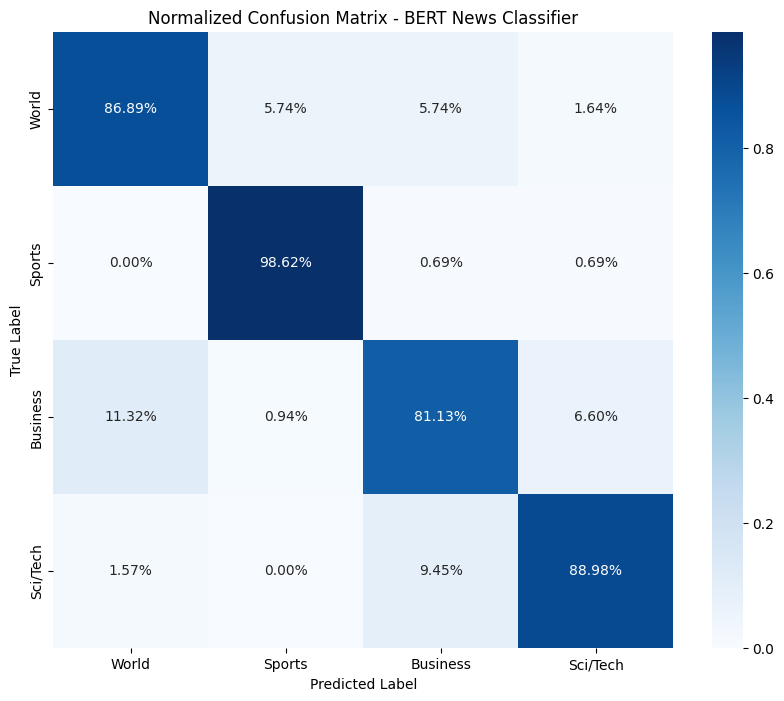

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Generate predictions on a subset of the test set (500 samples for efficient evaluation)
# trainer.predict returns predictions (logits) and the actual labels
eval_results = trainer.predict(tokenized_dataset["test"].select(range(500)))
y_preds = np.argmax(eval_results.predictions, axis=-1) # Convert logits to class indices
y_true = eval_results.label_ids

# Generate and print the Classification Report for detailed metrics per category
print("Classification Report:")
print(classification_report(y_true, y_preds, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

# Compute the Confusion Matrix
cm = confusion_matrix(y_true, y_preds)

# Normalize the matrix to show percentages instead of raw counts
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] 

# Create the heatmap visualization using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm_perc, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=['World', 'Sports', 'Business', 'Sci/Tech'], 
            yticklabels=['World', 'Sports', 'Business', 'Sci/Tech'])

# Add labels and title for professional presentation
plt.title('Normalized Confusion Matrix - BERT News Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

By fine-tuning **BERT-base-uncased** on a subset of the **AG News** dataset, this project achieved over **90% accuracy** within a single training epoch on a **CPU**. The evaluation metrics and confusion matrix confirm that the model effectively distinguishes between World, Sports, Business, and Sci/Tech categories with high precision. Finally, the integration of a **Gradio** interface successfully transitions the model from a training script to a functional, real-time application for automated news categorization.